## Data Loading

In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, TimeDistributed, Reshape, Lambda, Concatenate
from tensorflow.keras.layers import Softmax, Multiply
import tensorflow as tf
import json
import glob

In [36]:
# Load all JSON files from the Data subfolder and assign a sequential userID per file
data_dir = os.path.join('Data')
json_files = sorted(glob.glob(os.path.join(data_dir, '*.json')))
all_samples = []

for user_id, file in enumerate(json_files, start=1):
    with open(file, "r") as f:
        raw = json.load(f)

    if isinstance(raw, list):
        for session in raw:
            for sample in session['samples']:
                sample['userID'] = user_id
                all_samples.append(sample)
    else:
        for sample in raw['samples']:
            sample['userID'] = user_id
            all_samples.append(sample)

print(f"Loaded {len(json_files)} JSON files from '{data_dir}'")
print(f"Total samples: {len(all_samples)}")

# Extract samples
df_data = pd.DataFrame(all_samples)
df = pd.json_normalize(all_samples)

df_data.set_index('time', inplace=True)

Loaded 16 JSON files from 'Data'
Total samples: 242186


In [37]:
# Filter valid samples
df_data = df_data[df_data['user'].apply(lambda x: isinstance(x, dict)) & df_data['pois'].apply(lambda x: isinstance(x, list))]
print(f"Filtered data length: {len(df_data)}")

Filtered data length: 242186


In [38]:
print(df_data['user'].apply(type).value_counts())
print()
print(df_data['pois'].apply(type).value_counts())
print()
print(df_data.columns)

user
<class 'dict'>    242186
Name: count, dtype: int64

pois
<class 'list'>    242186
Name: count, dtype: int64

Index(['env', 'trial', 'user', 'pois', 'userID'], dtype='object')


## Flatten and Combine Features

In [39]:
def flatten_pois_safe(pois_list, user_yaw, max_pois=5):
    keys = ['dist', 'sin_angle', 'cos_angle', 'is_in_front', 'dist_weight']

    if not isinstance(pois_list, list):
        return {f'poi_{i}_{k}': 0 for i in range(max_pois) for k in keys}

    pois_list = sorted(pois_list, key=lambda x: x['distance'])

    flat = {}

    for i in range(max_pois):
        if i < len(pois_list):
            dist = pois_list[i]['distance']
            angle = pois_list[i]['angle']

            # Convert POI angle into user-relative frame for this timestep
            rel_angle = np.arctan2(
                np.sin(angle - user_yaw),
                np.cos(angle - user_yaw)
            )

            flat[f'poi_{i}_dist'] = dist
            flat[f'poi_{i}_sin_angle'] = np.sin(rel_angle)
            flat[f'poi_{i}_cos_angle'] = np.cos(rel_angle)
            flat[f'poi_{i}_is_in_front'] = 1 if abs(rel_angle) <= np.pi / 2 else 0
            flat[f'poi_{i}_dist_weight'] = 1 / (dist + 0.001)
        else:
            for k in keys:
                flat[f'poi_{i}_{k}'] = 0

    return flat

In [40]:
# Flatten user
user_df_full = pd.json_normalize(df_data['user'])
user_df_full.columns = ['x', 'z', 'vx', 'vz', 'yaw']

# Rotate velocities to local coordinate frame
user_df_full['vx_local'] = (
    user_df_full['vx'] * np.cos(user_df_full['yaw']) +
    user_df_full['vz'] * np.sin(user_df_full['yaw'])
)

user_df_full['vz_local'] = (
    -user_df_full['vx'] * np.sin(user_df_full['yaw']) +
    user_df_full['vz'] * np.cos(user_df_full['yaw'])
)

# Use original yaw here to make POIs user-relative
pois_df = pd.DataFrame([
    flatten_pois_safe(pois, yaw)
    for pois, yaw in zip(df_data['pois'], user_df_full['yaw'])
])

# Final user features
user_df = user_df_full[['x', 'z', 'vx_local', 'vz_local', 'yaw']]
user_df.columns = ['x', 'z', 'vx', 'vz', 'yaw']

In [41]:
df_final = pd.concat([
    df_data.reset_index()[['time', 'env', 'trial', 'userID']].reset_index(drop=True),
    user_df.reset_index(drop=True),
    pois_df.reset_index(drop=True)
], axis=1)

df_final = df_final.dropna()

## Round 1: Exclude Environment A

In [42]:
# Splitting by environment
test_env = 'A'

train_df = df_final[df_final['env'] != test_env]
test_df  = df_final[df_final['env'] == test_env]

In [43]:
 # Create sequences of 50 timesteps for LSTM, predicting displacement 50 timesteps ahead
# from tokenize import group


def create_sequences_grouped(df, seq_length=50, prediction_horizon=50):
    X, y = [], []
    
    for _, group in df.groupby(['env', 'trial']):
        
        group = group.reset_index(drop=True)
        
        # Drop non-feature columns
        positions = group[['x', 'z']].values

        features = group.drop(
            columns=['env', 'trial', 'time', 'userID', 'x', 'z']
        ).values
        
        for i in range(len(features) - seq_length - prediction_horizon + 1):
            X.append(features[i:i+seq_length])
            # Predict displacement: future position - current position
            current_pos = positions[i + seq_length - 1]
            future_pos = positions[i + seq_length + prediction_horizon - 1]
            displacement = future_pos - current_pos
            y.append(displacement)
    
    X = np.array(X)
    y = np.array(y)
    
    # Apply yaw normalization and rotate target displacement into sequence-relative frame
    for i in range(len(X)):
        mean_theta = np.mean(X[i, :, 2])
        cos_t = np.cos(mean_theta)
        sin_t = np.sin(mean_theta)

        # Normalize yaw only
        for j in range(seq_length):
            yaw = X[i, j, 2]
            X[i, j, 2] = np.arctan2(
                np.sin(yaw - mean_theta),
                np.cos(yaw - mean_theta)
            )

        # Rotate target displacement from world frame into sequence-relative frame
        dx = y[i, 0]
        dz = y[i, 1]

        y[i, 0] = dx * cos_t + dz * sin_t
        y[i, 1] = -dx * sin_t + dz * cos_t
    return X, y

In [44]:
# Generate timestep sequences
HISTORY_LENGTH = 50  # 2.5 seconds of history
PREDICTION_HORIZON = 50  # predict 2.5 seconds ahead
X_train, y_train = create_sequences_grouped(train_df, seq_length=HISTORY_LENGTH, prediction_horizon=PREDICTION_HORIZON)
X_test, y_test = create_sequences_grouped(test_df, seq_length=HISTORY_LENGTH, prediction_horizon=PREDICTION_HORIZON)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (191125, 50, 28), y_train shape: (191125, 2)
X_test shape: (45121, 50, 28), y_test shape: (45121, 2)


### POI Model Construction

In [45]:
# Build an LSTM model that encodes each POI via a shared MLP and mean-pools POI context
inputs = Input(shape=(HISTORY_LENGTH, 28), name='trajectory_input')

# Split user trajectory and POI features (skip userID at index 0)
user_features = Lambda(lambda x: x[:, :, :3], name='user_features')(inputs)  # vx, vz, yaw

# Suppose you have 5 POIs, each with 1+ features (here, 9 features for all POIs)
# Reshape to (batch, HISTORY_LENGTH, 5, 1+poi_feat_dim) if needed
poi_features = Lambda(lambda x: x[:, :, 3:], name='poi_raw')(inputs)
poi_reshaped = Reshape((HISTORY_LENGTH, 5, 5), name='poi_reshape')(poi_features)  # Adjust as needed

# Shared MLP for each POI
poi_encoded = TimeDistributed(TimeDistributed(Dense(32, activation='relu')), name='poi_mlp_1')(poi_reshaped)
poi_encoded = TimeDistributed(TimeDistributed(Dense(16, activation='relu')), name='poi_mlp_2')(poi_encoded)

# Distance-biased attention pooling across the 5 POIs
poi_scores = TimeDistributed(
    TimeDistributed(Dense(1)),
    name='learned_poi_scores'
)(poi_encoded)

poi_distances = Lambda(
    lambda x: x[:, :, :, 0:1],
    name='poi_distances'
)(poi_reshaped)

distance_bias = Lambda(
    lambda d: -d,
    name='distance_bias'
)(poi_distances)

combined_scores = Lambda(
    lambda x: x[0] + x[1],
    name='combined_attention_scores'
)([poi_scores, distance_bias])

poi_weights = Softmax(axis=2, name='poi_attention_weights')(combined_scores)

weighted_pois = Multiply(name='weighted_pois')([poi_encoded, poi_weights])

poi_context = Lambda(
    lambda x: tf.reduce_sum(x, axis=2),
    name='poi_attention_pool'
)(weighted_pois)

# Concatenate the POI context with user trajectory features
fused = Concatenate(axis=-1, name='trajectory_poi_fusion')([user_features, poi_context])

# Process fused sequence through LSTM stack
x = LSTM(64, return_sequences=True, name='lstm_1')(fused)
x = LSTM(64, name='lstm_2')(x)
x = Dropout(0.3, name='dropout')(x)
outputs = Dense(2, name='position_output')(x)

# Build model
model = tf.keras.Model(inputs=inputs, outputs=outputs, name='poicontext_lstm')

model.summary()

Model: "poicontext_lstm"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 trajectory_input (InputLay  [(None, 50, 28)]             0         []                            
 er)                                                                                              
                                                                                                  
 poi_raw (Lambda)            (None, 50, 25)               0         ['trajectory_input[0][0]']    
                                                                                                  
 poi_reshape (Reshape)       (None, 50, 5, 5)             0         ['poi_raw[0][0]']             
                                                                                                  
 poi_mlp_1 (TimeDistributed  (None, 50, 5, 32)            192       ['poi_reshape[0]

In [46]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

### POI Model Training

In [47]:
# Train the model
model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/100
2987/2987 [==============================] - 103s 33ms/step - loss: 1.5261 - mae: 0.9486 - val_loss: 1.6079 - val_mae: 0.9576
Epoch 2/100
2987/2987 [==============================] - 94s 31ms/step - loss: 1.1911 - mae: 0.8227 - val_loss: 1.5539 - val_mae: 0.9294
Epoch 3/100
2987/2987 [==============================] - 104s 35ms/step - loss: 1.0364 - mae: 0.7651 - val_loss: 1.5762 - val_mae: 0.9279
Epoch 4/100
2987/2987 [==============================] - 95s 32ms/step - loss: 0.9267 - mae: 0.7240 - val_loss: 1.5722 - val_mae: 0.9194
Epoch 5/100
2987/2987 [==============================] - 95s 32ms/step - loss: 0.8358 - mae: 0.6886 - val_loss: 1.6090 - val_mae: 0.9348
Epoch 6/100
2987/2987 [==============================] - 95s 32ms/step - loss: 0.7554 - mae: 0.6572 - val_loss: 1.6550 - val_mae: 0.9467
Epoch 7/100
2987/2987 [==============================] - 95s 32ms/step - loss: 0.6990 - mae: 0.6325 - val_loss: 1.6346 - val_mae: 0.9426
Epoch 8/100
2987/2987 [================

In [61]:
model.save("Exclude_Env_A_POI_Model.keras");

### POI Model Testing

In [ ]:
# make predictions
preds = model.predict(X_test)

1411/1411 [==============================] - 19s 13ms/step


In [49]:
# Baseline 1: zero displacement
preds_zero = np.zeros_like(y_test)

# Baseline 2: constant velocity
dt = 0.05
horizon_seconds = PREDICTION_HORIZON * dt

last_v = X_test[:, -1, :2]  # final vx, vz from input sequence
preds_cv = last_v * horizon_seconds

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_predictions(name, y_true, preds):
    mae_x = mean_absolute_error(y_true[:, 0], preds[:, 0])
    mae_z = mean_absolute_error(y_true[:, 1], preds[:, 1])

    rmse_x = np.sqrt(mean_squared_error(y_true[:, 0], preds[:, 0]))
    rmse_z = np.sqrt(mean_squared_error(y_true[:, 1], preds[:, 1]))

    mae_overall = (mae_x + mae_z) / 2
    rmse_overall = (rmse_x + rmse_z) / 2

    mde = np.mean(np.linalg.norm(preds - y_true, axis=1))

    pred_angles = np.arctan2(preds[:, 1], preds[:, 0])
    actual_angles = np.arctan2(y_true[:, 1], y_true[:, 0])

    angle_diff = pred_angles - actual_angles
    angle_diff = (angle_diff + np.pi) % (2 * np.pi) - np.pi

    actual_mag = np.linalg.norm(y_true, axis=1)
    valid = actual_mag > 0.05

    angular_error = np.mean(np.abs(angle_diff[valid]))

    print(f"\n{name}")
    print(f"MAE X: {mae_x:.4f}, Z: {mae_z:.4f}")
    print(f"RMSE X: {rmse_x:.4f}, Z: {rmse_z:.4f}")
    print(f"Overall MAE: {mae_overall:.4f}")
    print(f"Overall RMSE: {rmse_overall:.4f}")
    print(f"MDE: {mde:.4f}")
    print(f"Angular Error: {angular_error:.4f} radians")

    return {
        "Model": name,
        "MAE": mae_overall,
        "RMSE": rmse_overall,
        "MDE": mde,
        "Angular_Error": angular_error
    }

In [51]:
results = []

results.append(evaluate_predictions("POI Attention LSTM", y_test, preds))
results.append(evaluate_predictions("Zero Displacement Baseline", y_test, preds_zero))
results.append(evaluate_predictions("Constant Velocity Baseline", y_test, preds_cv))


POI Attention LSTM
MAE X: 1.0239, Z: 1.0380
RMSE X: 1.3902, Z: 1.4283
Overall MAE: 1.0310
Overall RMSE: 1.4092
MDE: 1.6197
Angular Error: 0.9026 radians

Zero Displacement Baseline
MAE X: 1.2922, Z: 1.2998
RMSE X: 1.5767, Z: 1.5882
Overall MAE: 1.2960
Overall RMSE: 1.5824
MDE: 2.0347
Angular Error: 1.5827 radians

Constant Velocity Baseline
MAE X: 1.5360, Z: 1.6443
RMSE X: 2.0460, Z: 2.3221
Overall MAE: 1.5902
Overall RMSE: 2.1841
MDE: 2.4954
Angular Error: 1.2661 radians


### Visualize Predictions

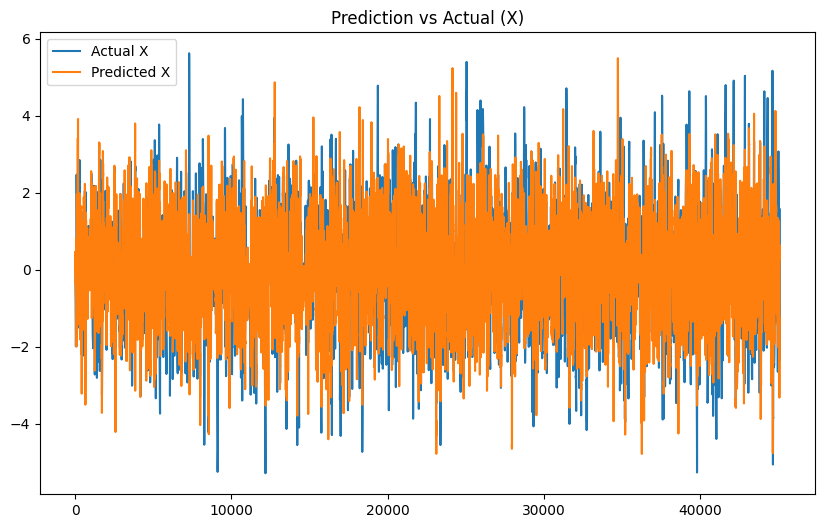

In [52]:
# Plot actual vs predicted for X
plt.figure(figsize=(10,6))

# Actual
plt.plot(y_test[:,0], label='Actual X')
# Predicted
plt.plot(preds[:,0], label='Predicted X')

plt.legend()
plt.title("Prediction vs Actual (X)")
plt.show()

In [53]:
# Select one trial from environment D
selected_trial = test_df['trial'].unique()[0]
test_df_single = test_df[test_df['trial'] == selected_trial]

# Create sequences for this single trial (each predicts 50 timesteps ahead)
X_test_single, y_test_single = create_sequences_grouped(test_df_single, seq_length=HISTORY_LENGTH, prediction_horizon=PREDICTION_HORIZON)
preds_single = model.predict(X_test_single)

# Get actual positions
actual_x = test_df_single['x'].values
actual_z = test_df_single['z'].values

# Current positions (end of each input sequence)
current_x = X_test_single[:, -1, 0]
current_z = X_test_single[:, -1, 1]

# Predicted next positions (50 timesteps ahead)
pred_x = preds_single[:, 0]
pred_z = preds_single[:, 1]

# Calculate POI positions (at the user's position when closest to each POI)
poi_x_list = []
poi_z_list = []
for poi in range(5):
    dist_col = f'poi_{poi}_dist'
    min_dist_idx = test_df_single[dist_col].idxmin()
    poi_x = test_df_single.loc[min_dist_idx, 'x']
    poi_z = test_df_single.loc[min_dist_idx, 'z']
    poi_x_list.append(poi_x)
    poi_z_list.append(poi_z)

# Plot interactive map
import plotly.graph_objects as go

fig = go.Figure()

# Add actual path
fig.add_trace(go.Scatter(x=actual_x, y=actual_z, mode='lines+markers', name='Actual Path', 
                         line=dict(color='blue', width=2), marker=dict(size=4)))

# Add start and end markers
fig.add_trace(go.Scatter(x=[actual_x[0]], y=[actual_z[0]], mode='markers', name='Start', 
                         marker=dict(color='green', size=10, symbol='star')))
fig.add_trace(go.Scatter(x=[actual_x[-1]], y=[actual_z[-1]], mode='markers', name='End', 
                         marker=dict(color='purple', size=10, symbol='star')))

# Add predicted jumps (50 timesteps ahead from each sequence end)
for i in range(len(current_x)):
    fig.add_trace(go.Scatter(x=[current_x[i], pred_x[i]], y=[current_z[i], pred_z[i]], 
                             mode='lines', name='Predicted Jump (2.5s ahead)' if i == 0 else '', 
                             line=dict(color='red', width=2, dash='dash'), showlegend=i==0))

# Add POIs
fig.add_trace(go.Scatter(x=poi_x_list, y=poi_z_list, mode='markers', name='POIs', 
                         marker=dict(color='green', size=6, symbol='x')))

fig.update_layout(
    title=f'Map of Actual and Predicted User Walking Paths (Environment D, Trial {selected_trial}) - Predicting 2.5s Ahead',
    xaxis_title='X Position',
    yaxis_title='Z Position',
    width=800,
    height=600
)

fig.show()

116/116 [==============================] - 2s 14ms/step


### Evaluate POI Model Performance

POI Distance Statistics:
          poi_0_dist     poi_1_dist     poi_2_dist     poi_3_dist  \
count  242186.000000  242186.000000  242186.000000  242186.000000   
mean        1.767911       1.908365       1.710028       1.409523   
std         1.066783       1.451705       1.729383       1.898644   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.975440       0.000000       0.000000       0.000000   
50%         1.502226       1.973181       1.863464       0.000000   
75%         2.274528       2.856164       3.121595       3.188754   
max         6.432596       6.346470       6.536422       6.392745   

          poi_4_dist  
count  242186.000000  
mean        0.904331  
std         1.798342  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.000000  
max         6.431860  

POI Sin Angle Statistics:
       poi_0_sin_angle  poi_1_sin_angle  poi_2_sin_angle  poi_3_sin_angle  \
count    242186.000000    242186.000000   

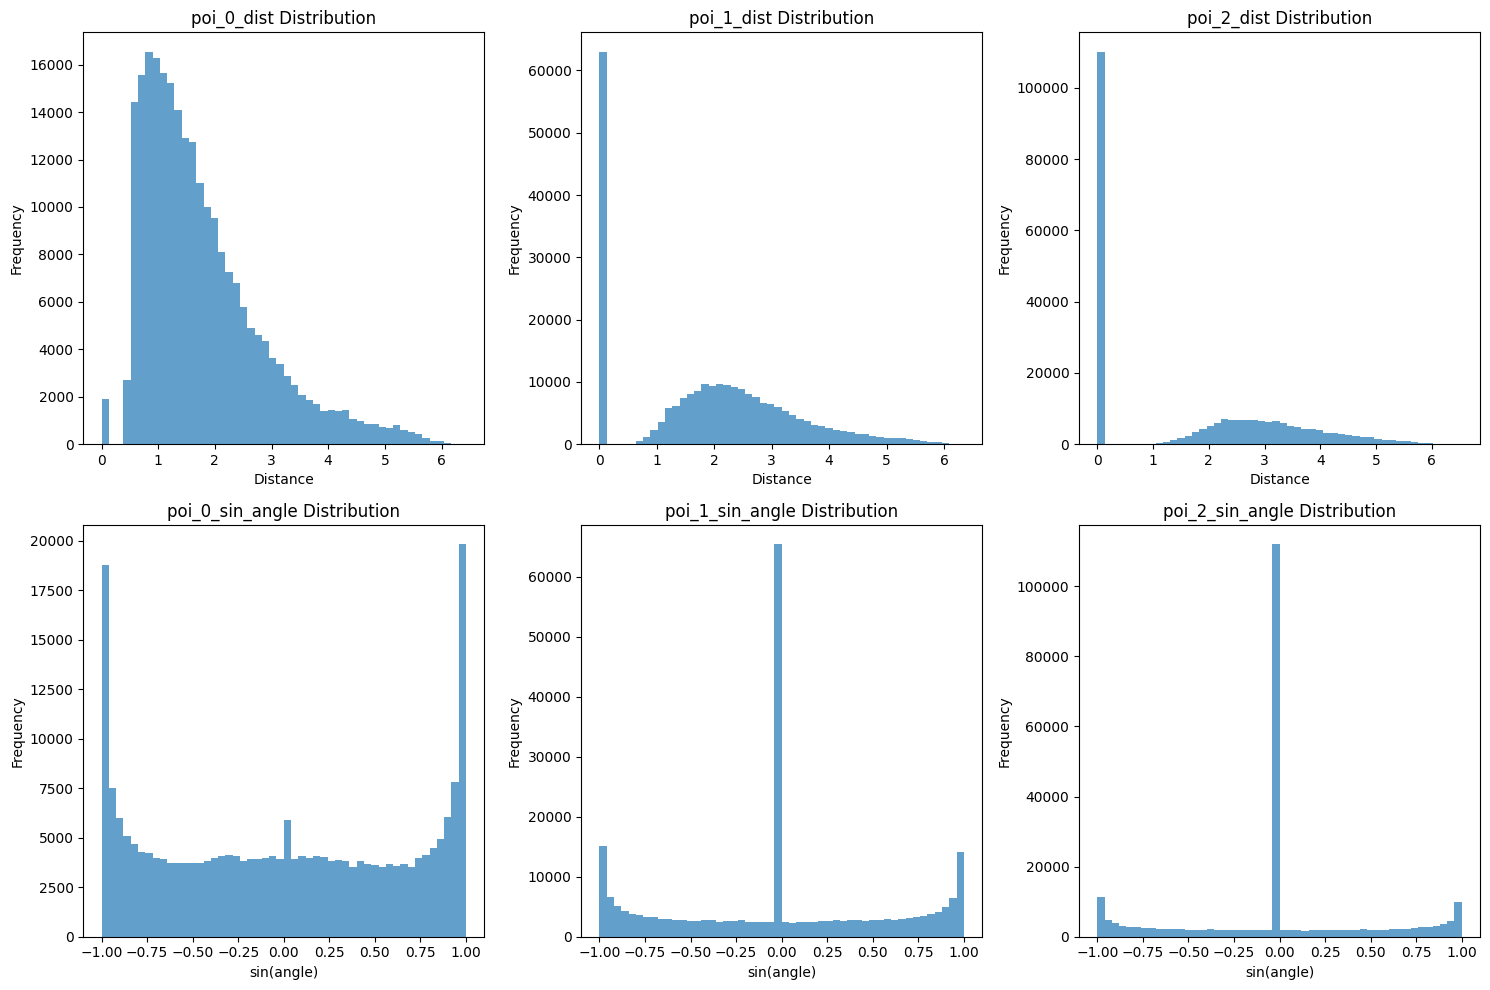


Sample sin(angle): 0   -0.752591
1   -0.753351
2   -0.758404
3   -0.761488
4   -0.764149
Name: poi_0_sin_angle, dtype: float64
sin(angle) range: -1.000 to 1.000

Sample cos(angle): 0    0.658488
1    0.657618
2    0.651785
3    0.648180
4    0.645040
Name: poi_0_cos_angle, dtype: float64
cos(angle) range: -1.000 to 1.000

Yaw range: -3.142 to 3.142


In [54]:
# Analyze POI data validity
import matplotlib.pyplot as plt

poi_dist_cols = [col for col in df_final.columns if 'poi' in col and 'dist' in col and 'weight' not in col]
poi_sin_cols = [col for col in df_final.columns if 'poi' in col and 'sin_angle' in col]
poi_cos_cols = [col for col in df_final.columns if 'poi' in col and 'cos_angle' in col]

print("POI Distance Statistics:")
print(df_final[poi_dist_cols].describe())

print("\nPOI Sin Angle Statistics:")
print(df_final[poi_sin_cols].describe())

print("\nPOI Cos Angle Statistics:")
print(df_final[poi_cos_cols].describe())

# Check correlation between yaw and POI features
yaw_col = 'yaw'

corrs_yaw_sin = df_final[[yaw_col] + poi_sin_cols].corr()
corrs_yaw_cos = df_final[[yaw_col] + poi_cos_cols].corr()

print("\nCorrelation between yaw and POI sin(angle):")
print(corrs_yaw_sin[yaw_col])

print("\nCorrelation between yaw and POI cos(angle):")
print(corrs_yaw_cos[yaw_col])

# Plot distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, col in enumerate(poi_dist_cols[:3]):
    axes[0, i].hist(df_final[col], bins=50, alpha=0.7)
    axes[0, i].set_title(f'{col} Distribution')
    axes[0, i].set_xlabel('Distance')
    axes[0, i].set_ylabel('Frequency')

for i, col in enumerate(poi_sin_cols[:3]):
    axes[1, i].hist(df_final[col], bins=50, alpha=0.7)
    axes[1, i].set_title(f'{col} Distribution')
    axes[1, i].set_xlabel('sin(angle)')
    axes[1, i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Check ranges
print(f"\nSample sin(angle): {df_final[poi_sin_cols[0]].head()}")
print(f"sin(angle) range: {df_final[poi_sin_cols[0]].min():.3f} to {df_final[poi_sin_cols[0]].max():.3f}")

print(f"\nSample cos(angle): {df_final[poi_cos_cols[0]].head()}")
print(f"cos(angle) range: {df_final[poi_cos_cols[0]].min():.3f} to {df_final[poi_cos_cols[0]].max():.3f}")

print(f"\nYaw range: {df_final[yaw_col].min():.3f} to {df_final[yaw_col].max():.3f}")

In [55]:
# Check correlations between POI features and target positions
poi_cols = [col for col in df_final.columns if 'poi' in col]
target_cols = ['x', 'z']

corrs = df_final[poi_cols + target_cols].corr()
print("Correlations between POI features and positions:")
print(corrs.loc[poi_cols, target_cols])

# Also check with velocities and yaw
all_features = ['x', 'z', 'vx', 'vz', 'yaw'] + poi_cols
corrs_full = df_final[all_features].corr()
print("\nFull feature correlations with x and z:")
print(corrs_full.loc[all_features, ['x', 'z']])

# Check if POI features have predictive power
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Simple linear regression for each POI feature to x
for col in poi_cols:
    X_feat = df_final[[col]]
    y_x = df_final['x']
    model_x = LinearRegression().fit(X_feat, y_x)
    r2_x = r2_score(y_x, model_x.predict(X_feat))
    
    y_z = df_final['z']
    model_z = LinearRegression().fit(X_feat, y_z)
    r2_z = r2_score(y_z, model_z.predict(X_feat))
    
    print(f"{col}: R² with x = {r2_x:.4f}, with z = {r2_z:.4f}")

Correlations between POI features and positions:
                          x         z
poi_0_dist         0.004100 -0.001602
poi_0_sin_angle    0.001689 -0.055703
poi_0_cos_angle   -0.024572  0.071972
poi_0_is_in_front -0.021069  0.065554
poi_0_dist_weight  0.003595 -0.003493
poi_1_dist        -0.014937 -0.026769
poi_1_sin_angle    0.109229 -0.050508
poi_1_cos_angle   -0.029263  0.011836
poi_1_is_in_front -0.034826 -0.010136
poi_1_dist_weight -0.016935 -0.035752
poi_2_dist        -0.013574 -0.043339
poi_2_sin_angle    0.100123 -0.055151
poi_2_cos_angle   -0.046227  0.037010
poi_2_is_in_front -0.041342  0.001516
poi_2_dist_weight -0.012337 -0.041651
poi_3_dist        -0.013234 -0.030513
poi_3_sin_angle    0.066311 -0.050219
poi_3_cos_angle   -0.053650  0.026235
poi_3_is_in_front -0.045093  0.003115
poi_3_dist_weight -0.011307 -0.023909
poi_4_dist         0.002375  0.002682
poi_4_sin_angle    0.055533 -0.047950
poi_4_cos_angle   -0.049235  0.020808
poi_4_is_in_front -0.031860  0.018500
p

### Baseline Model Construction

In [56]:
# Features without POIs: vx, vz, yaw (3 features, indices 0:3)
X_train_no_poi = X_train[:, :, :3]
X_test_no_poi = X_test[:, :, :3]

model_no_poi = Sequential([
    LSTM(64, input_shape=(HISTORY_LENGTH, 3), return_sequences=True),
    LSTM(64),
    Dropout(0.3),
    Dense(2)
])

model_no_poi.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

### Baseline Model Training

In [57]:
#Training model without POI features
history_no_poi = model_no_poi.fit(
    X_train_no_poi, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_test_no_poi, y_test),
    verbose=0
)

In [64]:
model_no_poi.save("Exclude_Env_A_Baseline_Model.keras");

### Baseline Model Testing

In [58]:
preds_no_poi = model_no_poi.predict(X_test_no_poi)

results.append(evaluate_predictions("No-POI LSTM Baseline", y_test, preds_no_poi))

results_df = pd.DataFrame(results)
print(results_df)

1411/1411 [==============================] - 11s 8ms/step

No-POI LSTM Baseline
MAE X: 1.1863, Z: 1.1828
RMSE X: 1.5712, Z: 1.5858
Overall MAE: 1.1845
Overall RMSE: 1.5785
MDE: 1.8630
Angular Error: 1.0599 radians
                        Model       MAE      RMSE       MDE  Angular_Error
0          POI Attention LSTM  1.030958  1.409209  1.619687       0.902633
1  Zero Displacement Baseline  1.296014  1.582445  2.034650       1.582743
2  Constant Velocity Baseline  1.590166  2.184079  2.495407       1.266093
3        No-POI LSTM Baseline  1.184548  1.578481  1.862975       1.059850


### POI vs Baseline Model Comparison

In [59]:
# mae_x_no_poi = mean_absolute_error(y_test[:, 0], preds_no_poi[:, 0])
# mae_z_no_poi = mean_absolute_error(y_test[:, 1], preds_no_poi[:, 1])
# rmse_x_no_poi = np.sqrt(mean_squared_error(y_test[:, 0], preds_no_poi[:, 0]))
# rmse_z_no_poi = np.sqrt(mean_squared_error(y_test[:, 1], preds_no_poi[:, 1]))

# print(f"Baseline Round 1 - MAE X: {mae_x_no_poi:.4f}, Z: {mae_z_no_poi:.4f}")
# print(f"Baseline Round 1 - RMSE X: {rmse_x_no_poi:.4f}, Z: {rmse_z_no_poi:.4f}")

# mae_overall_no_poi = (mae_x_no_poi + mae_z_no_poi) / 2
# rmse_overall_no_poi = (rmse_x_no_poi + rmse_z_no_poi) / 2
# print(f"Baseline Round 1 - Overall MAE: {mae_overall_no_poi:.4f}, RMSE: {rmse_overall_no_poi:.4f}")

# # MDE for baseline
# mde_no_poi = np.mean(np.linalg.norm(preds_no_poi - y_test, axis=1))
# print(f"Baseline MDE: {mde_no_poi:.4f}")

# # Angular Error for baseline
# pred_angles_no_poi = np.arctan2(preds_no_poi[:, 1], preds_no_poi[:, 0])
# angle_diff_no_poi = pred_angles_no_poi - actual_angles
# angle_diff_no_poi = (angle_diff_no_poi + np.pi) % (2 * np.pi) - np.pi
# angular_error_no_poi = np.mean(np.abs(angle_diff_no_poi))
# print(f"Baseline Angular Error: {angular_error_no_poi:.4f} radians")

# # Comparison
# print(f"\nComparison for Round 1:")
# print(f"POI Model - MAE: {mae_overall:.4f}, RMSE: {rmse_overall:.4f}, MDE: {mde:.4f}, Angular: {angular_error:.4f}")
# print(f"Baseline - MAE: {mae_overall_no_poi:.4f}, RMSE: {rmse_overall_no_poi:.4f}, MDE: {mde_no_poi:.4f}, Angular: {angular_error_no_poi:.4f}")

# if mae_overall < mae_overall_no_poi:
#     print("POI features improve model performance.")
# else:
#     print("POI features do not improve (or worsen) model performance.")

## Round 2: Exclude Environment B

In [16]:
# Data Splitting for Round 2
test_env = 'B'

train_df_2 = df_final[df_final['env'] != test_env]
test_df_2  = df_final[df_final['env'] == test_env]

In [17]:
# Generate timestep sequences
X_train2, y_train2 = create_sequences_grouped(train_df_2, seq_length=HISTORY_LENGTH, prediction_horizon=PREDICTION_HORIZON)
X_test2, y_test2 = create_sequences_grouped(test_df_2, seq_length=HISTORY_LENGTH, prediction_horizon=PREDICTION_HORIZON)
print(f"X_train shape: {X_train2.shape}, y_train shape: {y_train2.shape}")
print(f"X_test shape: {X_test2.shape}, y_test shape: {y_test2.shape}")

X_train shape: (95448, 50, 28), y_train shape: (95448, 2)
X_test shape: (23308, 50, 28), y_test shape: (23308, 2)


### POI Model Construction

In [18]:
# Build an LSTM model that encodes each POI via a shared MLP and mean-pools POI context
inputs = Input(shape=(HISTORY_LENGTH, 28), name='trajectory_input')

# Split user trajectory and POI features (skip userID at index 0)
user_features = Lambda(lambda x: x[:, :, :3], name='user_features')(inputs)  # vx, vz, yaw

# Suppose you have 5 POIs, each with 1+ features (here, 9 features for all POIs)
# Reshape to (batch, HISTORY_LENGTH, 5, 1+poi_feat_dim) if needed
poi_features = Lambda(lambda x: x[:, :, 3:], name='poi_raw')(inputs)
poi_reshaped = Reshape((HISTORY_LENGTH, 5, 5), name='poi_reshape')(poi_features)  # Adjust as needed

# Shared MLP for each POI
poi_encoded = TimeDistributed(TimeDistributed(Dense(32, activation='relu')), name='poi_mlp_1')(poi_reshaped)
poi_encoded = TimeDistributed(TimeDistributed(Dense(16, activation='relu')), name='poi_mlp_2')(poi_encoded)

# Distance-biased attention pooling across the 5 POIs
poi_scores = TimeDistributed(
    TimeDistributed(Dense(1)),
    name='learned_poi_scores'
)(poi_encoded)

poi_distances = Lambda(
    lambda x: x[:, :, :, 0:1],
    name='poi_distances'
)(poi_reshaped)

distance_bias = Lambda(
    lambda d: -d,
    name='distance_bias'
)(poi_distances)

combined_scores = Lambda(
    lambda x: x[0] + x[1],
    name='combined_attention_scores'
)([poi_scores, distance_bias])

poi_weights = Softmax(axis=2, name='poi_attention_weights')(combined_scores)

weighted_pois = Multiply(name='weighted_pois')([poi_encoded, poi_weights])

poi_context = Lambda(
    lambda x: tf.reduce_sum(x, axis=2),
    name='poi_attention_pool'
)(weighted_pois)

# Concatenate the POI context with user trajectory features
fused = Concatenate(axis=-1, name='trajectory_poi_fusion')([user_features, poi_context])

# Process fused sequence through LSTM stack
x = LSTM(64, return_sequences=True, name='lstm_1')(fused)
x = LSTM(64, name='lstm_2')(x)
x = Dropout(0.3, name='dropout')(x)
outputs = Dense(2, name='position_output')(x)

# Build model
model_2= tf.keras.Model(inputs=inputs, outputs=outputs, name='poicontext_lstm')

model_2.summary()

Model: "poicontext_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ trajectory_input    │ (None, 50, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ poi_raw (Lambda)    │ (None, 50, 25)    │          0 │ trajectory_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ poi_reshape         │ (None, 50, 5, 5)  │          0 │ poi_raw[0][0]     │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ poi_mlp_1           │ (None, 50, 5, 32) │        192 │ poi_reshape[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ poi_mlp_2           │ (None, 50, 5, 16) │        528 │ poi_mlp_1[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ poi_distances       │ (None, 50, 5, 1)  │          0 │ poi_reshape[0][0] │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ learned_poi_scores  │ (None, 50, 5, 1)  │         17 │ poi_mlp_2[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ distance_bias       │ (None, 50, 5, 1)  │          0 │ poi_distances[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_attention… │ (None, 50, 5, 1)  │          0 │ learned_poi_scor… │
│ (Lambda)            │                   │            │ distance_bias[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ poi_attention_weig… │ (None, 50, 5, 1)  │          0 │ combined_attenti… │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_pois       │ (None, 50, 5, 16) │          0 │ poi_mlp_2[0][0],  │
│ (Multiply)          │                   │            │ poi_attention_we… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_features       │ (None, 50, 3)     │          0 │ trajectory_input… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ poi_attention_pool  │ (None, 50, 16)    │          0 │ weighted_pois[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trajectory_poi_fus… │ (None, 50, 19)    │          0 │ user_features[0]… │
│ (Concatenate)       │                   │            │ poi_attention_po… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 50, 64)    │     21,504 │ trajectory_poi_f… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     33,024 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_output     │ (None, 2)         │        130 │ dropout[0][0]     │
│ (Dense)             │                   │            │                 

 Total params: 55,395 (216.39 KB)

 Trainable params: 55,395 (216.39 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

### POI Model Training

In [20]:
# Train the model
model_2.fit(
    X_train2, y_train2,
    epochs=100,
    batch_size=64,
    validation_data=(X_test2, y_test2)
)

Epoch 1/100
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - loss: 1.8273 - mae: 1.0599 - val_loss: 1.8085 - val_mae: 1.0506
Epoch 2/100
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 56s 38ms/step - loss: 1.3338 - mae: 0.8848 - val_loss: 1.7517 - val_mae: 1.0407
Epoch 3/100
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 54s 36ms/step - loss: 1.1129 - mae: 0.8026 - val_loss: 1.8173 - val_mae: 1.0298
Epoch 4/100
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 53s 36ms/step - loss: 0.9613 - mae: 0.7424 - val_loss: 1.8661 - val_mae: 1.0514
Epoch 5/100
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - loss: 0.8390 - mae: 0.6940 - val_loss: 1.9398 - val_mae: 1.0570
Epoch 6/100
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - loss: 0.7400 - mae: 0.6528 - val_loss: 1.9598 - val_mae: 1.0684
Epoch 7/100
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - loss: 0.6616 - mae: 0.6165 - val_loss: 2.0273 - val_mae: 1.0887
Epoch 8/100
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 53s 36ms/step - loss: 0.6064 - mae: 0.5906 - val_loss: 2.0261 - val_mae: 1.0827
Epoch 9/100
1492

In [ ]:
model_2.save("Exclude_Env_B_POI_Model.keras");

### POI Model Testing

In [21]:
# Make predictions for Round 2
preds_2 = model_2.predict(X_test2)

729/729 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step


In [30]:
# Baseline 1: zero displacement
preds_zero_2 = np.zeros_like(y_test2)

# Baseline 2: constant velocity
dt = 0.05
horizon_seconds_2 = PREDICTION_HORIZON * dt

last_v_2 = X_test2[:, -1, :2]  # final vx, vz from input sequence
preds_cv_2 = last_v_2 * horizon_seconds_2

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_predictions(name, y_true, preds):
    mae_x = mean_absolute_error(y_true[:, 0], preds[:, 0])
    mae_z = mean_absolute_error(y_true[:, 1], preds[:, 1])

    rmse_x = np.sqrt(mean_squared_error(y_true[:, 0], preds[:, 0]))
    rmse_z = np.sqrt(mean_squared_error(y_true[:, 1], preds[:, 1]))

    mae_overall = (mae_x + mae_z) / 2
    rmse_overall = (rmse_x + rmse_z) / 2

    mde = np.mean(np.linalg.norm(preds - y_true, axis=1))

    pred_angles = np.arctan2(preds[:, 1], preds[:, 0])
    actual_angles = np.arctan2(y_true[:, 1], y_true[:, 0])

    angle_diff = pred_angles - actual_angles
    angle_diff = (angle_diff + np.pi) % (2 * np.pi) - np.pi

    actual_mag = np.linalg.norm(y_true, axis=1)
    valid = actual_mag > 0.05

    angular_error = np.mean(np.abs(angle_diff[valid]))

    print(f"\n{name}")
    print(f"MAE X: {mae_x:.4f}, Z: {mae_z:.4f}")
    print(f"RMSE X: {rmse_x:.4f}, Z: {rmse_z:.4f}")
    print(f"Overall MAE: {mae_overall:.4f}")
    print(f"Overall RMSE: {rmse_overall:.4f}")
    print(f"MDE: {mde:.4f}")
    print(f"Angular Error: {angular_error:.4f} radians")

    return {
        "Model": name,
        "MAE": mae_overall,
        "RMSE": rmse_overall,
        "MDE": mde,
        "Angular_Error": angular_error
    }

In [33]:
results = []

results.append(evaluate_predictions("POI Attention LSTM", y_test2, preds_2))
results.append(evaluate_predictions("Zero Displacement Baseline", y_test2, preds_zero_2))
results.append(evaluate_predictions("Constant Velocity Baseline", y_test2, preds_cv_2))


POI Attention LSTM
MAE X: 1.1258, Z: 1.1201
RMSE X: 1.4594, Z: 1.4756
Overall MAE: 1.1230
Overall RMSE: 1.4675
MDE: 1.7633
Angular Error: 0.9614 radians

Zero Displacement Baseline
MAE X: 1.3375, Z: 1.3825
RMSE X: 1.6133, Z: 1.6753
Overall MAE: 1.3600
Overall RMSE: 1.6443
MDE: 2.1368
Angular Error: 1.5902 radians

Constant Velocity Baseline
MAE X: 1.7079, Z: 1.8484
RMSE X: 2.4160, Z: 2.7037
Overall MAE: 1.7782
Overall RMSE: 2.5598
MDE: 2.7809
Angular Error: 1.3415 radians


### Evaluate POI Model Performance

In [35]:
# Check correlations between POI features and target positions
poi_cols2 = [col for col in df_final.columns if 'poi' in col]
target_cols2 = ['x', 'z']

corrs2 = df_final[poi_cols2 + target_cols2].corr()
print("Correlations between POI features and positions:")
print(corrs.loc[poi_cols2, target_cols2])

# Also check with velocities and yaw
all_features2 = ['x', 'z', 'vx', 'vz', 'yaw'] + poi_cols2
corrs_full2 = df_final[all_features2].corr()
print("\nFull feature correlations with x and z:")
print(corrs_full2.loc[all_features2, ['x', 'z']])

# Check if POI features have predictive power
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Simple linear regression for each POI feature to x
for col in poi_cols2:
    X_feat = df_final[[col]]
    y_x = df_final['x']
    model_x = LinearRegression().fit(X_feat, y_x)
    r2_x = r2_score(y_x, model_x.predict(X_feat))
    
    y_z = df_final['z']
    model_z = LinearRegression().fit(X_feat, y_z)
    r2_z = r2_score(y_z, model_z.predict(X_feat))
    
    print(f"{col}: R² with x = {r2_x:.4f}, with z = {r2_z:.4f}")

Correlations between POI features and positions:
                          x         z
poi_0_dist         0.018859  0.032302
poi_0_sin_angle   -0.010876 -0.075142
poi_0_cos_angle   -0.037898  0.084164
poi_0_is_in_front -0.030934  0.077144
poi_0_dist_weight -0.003206 -0.018100
poi_1_dist         0.028092 -0.052404
poi_1_sin_angle    0.106357 -0.067551
poi_1_cos_angle   -0.049039  0.019772
poi_1_is_in_front -0.034229 -0.022036
poi_1_dist_weight -0.006642 -0.055861
poi_2_dist         0.028564 -0.074902
poi_2_sin_angle    0.083445 -0.062839
poi_2_cos_angle   -0.066502  0.054204
poi_2_is_in_front -0.041158 -0.004246
poi_2_dist_weight  0.004947 -0.061665
poi_3_dist         0.005125 -0.053141
poi_3_sin_angle    0.050161 -0.055555
poi_3_cos_angle   -0.066478  0.041375
poi_3_is_in_front -0.048781  0.001771
poi_3_dist_weight -0.015335 -0.034709
poi_4_dist        -0.015937 -0.004264
poi_4_sin_angle    0.034184 -0.047334
poi_4_cos_angle   -0.053463  0.018864
poi_4_is_in_front -0.050198  0.008204
p

In [ ]:
# # Evaluate model performance for Round 2
# mae_x_2 = mean_absolute_error(y_test_2[:, 0], preds_2[:, 0])
# mae_z_2 = mean_absolute_error(y_test_2[:, 1], preds_2[:, 1])
# rmse_x_2 = np.sqrt(mean_squared_error(y_test_2[:, 0], preds_2[:, 0]))
# rmse_z_2 = np.sqrt(mean_squared_error(y_test_2[:, 1], preds_2[:, 1]))

# print(f"Round 2 - Test MAE - X: {mae_x_2:.4f}, Z: {mae_z_2:.4f}")
# print(f"Round 2 - Test RMSE - X: {rmse_x_2:.4f}, Z: {rmse_z_2:.4f}")

# # Overall MAE and RMSE
# mae_overall_2 = (mae_x_2 + mae_z_2) / 2
# rmse_overall_2 = (rmse_x_2 + rmse_z_2) / 2
# print(f"Round 2 - Overall MAE: {mae_overall_2:.4f}, RMSE: {rmse_overall_2:.4f}")

# # MDE
# mde_2 = np.mean(np.linalg.norm(preds_2 - y_test_2, axis=1))
# print(f"Round 2 - MDE: {mde_2:.4f}")

# # Angular Error
# pred_angles_2 = np.arctan2(preds_2[:, 1], preds_2[:, 0])
# actual_angles_2 = np.arctan2(y_test_2[:, 1], y_test_2[:, 0])
# angle_diff_2 = pred_angles_2 - actual_angles_2
# angle_diff_2 = (angle_diff_2 + np.pi) % (2 * np.pi) - np.pi
# angular_error_2 = np.mean(np.abs(angle_diff_2))
# print(f"Round 2 - Angular Error: {angular_error_2:.4f} radians")

### Baseline Model Construction

In [36]:
# Features without POIs: vx, vz, yaw (3 features)
X_train_no_poi_2 = X_train2[:, :, :3]
X_test_no_poi_2 = X_test2[:, :, :3]

model_no_poi_2 = Sequential([
    LSTM(64, input_shape=(HISTORY_LENGTH, 3), return_sequences=True),
    LSTM(64),
    Dropout(0.3),
    Dense(2)
])

model_no_poi_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

c:\Users\JetPa\anaconda3\envs\mnist_tf2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Baseline Model Training

In [37]:
# Training baseline model for Round 2
history_no_poi_2 = model_no_poi_2.fit(
    X_train_no_poi_2, y_train2,
    epochs=100,
    batch_size=64,
    validation_data=(X_test_no_poi_2, y_test2),
    verbose=0
)

KeyboardInterrupt: 

In [ ]:
model_no_poi_2.save("Exclude_Env_B_Baseline_Model.keras");

### Baseline Model Testing

In [ ]:
preds_no_poi2 = model_no_poi.predict(X_test_no_poi_2)

results.append(evaluate_predictions("No-POI LSTM Baseline", y_test2, preds_no_poi2))

results_df2 = pd.DataFrame(results)
print(results_df2)

### POI vs Baseline Model Comparison

In [ ]:
# mae_x_no_poi_2 = mean_absolute_error(y_test_2[:, 0], preds_no_poi_2[:, 0])
# mae_z_no_poi_2 = mean_absolute_error(y_test_2[:, 1], preds_no_poi_2[:, 1])
# rmse_x_no_poi_2 = np.sqrt(mean_squared_error(y_test_2[:, 0], preds_no_poi_2[:, 0]))
# rmse_z_no_poi_2 = np.sqrt(mean_squared_error(y_test_2[:, 1], preds_no_poi_2[:, 1]))

# print(f"Baseline Round 2 - MAE X: {mae_x_no_poi_2:.4f}, Z: {mae_z_no_poi_2:.4f}")
# print(f"Baseline Round 2 - RMSE X: {rmse_x_no_poi_2:.4f}, Z: {rmse_z_no_poi_2:.4f}")

# mae_overall_no_poi_2 = (mae_x_no_poi_2 + mae_z_no_poi_2) / 2
# rmse_overall_no_poi_2 = (rmse_x_no_poi_2 + rmse_z_no_poi_2) / 2
# print(f"Baseline Round 2 - Overall MAE: {mae_overall_no_poi_2:.4f}, RMSE: {rmse_overall_no_poi_2:.4f}")

# # MDE for baseline
# mde_no_poi_2 = np.mean(np.linalg.norm(preds_no_poi_2 - y_test_2, axis=1))
# print(f"Baseline Round 2 - MDE: {mde_no_poi_2:.4f}")

# # Angular Error for baseline
# pred_angles_no_poi_2 = np.arctan2(preds_no_poi_2[:, 1], preds_no_poi_2[:, 0])
# angle_diff_no_poi_2 = pred_angles_no_poi_2 - actual_angles_2
# angle_diff_no_poi_2 = (angle_diff_no_poi_2 + np.pi) % (2 * np.pi) - np.pi
# angular_error_no_poi_2 = np.mean(np.abs(angle_diff_no_poi_2))
# print(f"Baseline Round 2 - Angular Error: {angular_error_no_poi_2:.4f} radians")

# # Comparison
# print(f"\nComparison for Round 2:")
# print(f"POI Model - MAE: {mae_overall_2:.4f}, RMSE: {rmse_overall_2:.4f}, MDE: {mde_2:.4f}, Angular: {angular_error_2:.4f}")
# print(f"Baseline - MAE: {mae_overall_no_poi_2:.4f}, RMSE: {rmse_overall_no_poi_2:.4f}, MDE: {mde_no_poi_2:.4f}, Angular: {angular_error_no_poi_2:.4f}")

# if mae_overall_2 < mae_overall_no_poi_2:
#     print("POI features improve model performance in Round 2.")
# else:
#     print("POI features do not improve (or worsen) model performance in Round 2.")

## Round 3: Exclude Environment C

In [ ]:
# Data Splitting for Round 3
test_env = 'C'

train_df_3 = df_final[df_final['env'] != test_env]
test_df_3  = df_final[df_final['env'] == test_env]

In [ ]:
# Generate timestep sequences for Round 3
X_train_3, y_train_3 = create_sequences_grouped(train_df_3, seq_length=HISTORY_LENGTH, prediction_horizon=PREDICTION_HORIZON)
X_test_3, y_test_3 = create_sequences_grouped(test_df_3, seq_length=HISTORY_LENGTH, prediction_horizon=PREDICTION_HORIZON)
print(f"X_train_3 shape: {X_train_3.shape}, y_train_3 shape: {y_train_3.shape}")
print(f"X_test_3 shape: {X_test_3.shape}, y_test_3 shape: {y_test_3.shape}")

### POI Model Construction

In [ ]:
# Build an LSTM model that encodes each POI via a shared MLP and mean-pools POI context
inputs_3 = Input(shape=(HISTORY_LENGTH, 28), name='trajectory_input')

# Split user trajectory and POI features (skip userID at index 0)
user_features_3 = Lambda(lambda x: x[:, :, :3], name='user_features')(inputs_3)  # vx, vz, yaw

# Suppose you have 5 POIs, each with 1+ features (here, 9 features for all POIs)
# Reshape to (batch, HISTORY_LENGTH, 5, 1+poi_feat_dim) if needed
poi_features_3 = Lambda(lambda x: x[:, :, 3:], name='poi_raw')(inputs_3)
poi_reshaped_3 = Reshape((HISTORY_LENGTH, 5, 5), name='poi_reshape')(poi_features_3)  # Adjust as needed

# Shared MLP for each POI
poi_encoded_3 = TimeDistributed(TimeDistributed(Dense(32, activation='relu')), name='poi_mlp_1')(poi_reshaped_3)
poi_encoded_3 = TimeDistributed(TimeDistributed(Dense(16, activation='relu')), name='poi_mlp_2')(poi_encoded_3)

# Distance-biased attention pooling across the 5 POIs
poi_scores_3 = TimeDistributed(
    TimeDistributed(Dense(1)),
    name='learned_poi_scores'
)(poi_encoded_3)

poi_distances_3 = Lambda(
    lambda x: x[:, :, :, 0:1],
    name='poi_distances'
)(poi_reshaped_3)

distance_bias_3 = Lambda(
    lambda d: -d,
    name='distance_bias'
)(poi_distances_3)

combined_scores_3 = Lambda(
    lambda x: x[0] + x[1],
    name='combined_attention_scores'
)([poi_scores_3, distance_bias_3])

poi_weights_3 = Softmax(axis=2, name='poi_attention_weights')(combined_scores_3)

weighted_pois_3 = Multiply(name='weighted_pois')([poi_encoded_3, poi_weights_3])

poi_context_3 = Lambda(
    lambda x: tf.reduce_sum(x, axis=2),
    name='poi_attention_pool'
)(weighted_pois_3)

# Concatenate the POI context with user trajectory features
fused_3 = Concatenate(axis=-1, name='trajectory_poi_fusion')([user_features_3, poi_context])

# Process fused sequence through LSTM stack
x_3 = LSTM(64, return_sequences=True, name='lstm_1')(fused_3)
x_3 = LSTM(64, name='lstm_2')(x_3)
x_3 = Dropout(0.3, name='dropout')(x_3)
outputs_3 = Dense(2, name='position_output')(x_3)

# Build model
model_3 = tf.keras.Model(inputs=inputs_3, outputs=outputs_3, name='poicontext_lstm')

model_3.summary()

In [ ]:
model_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

### POI Model Training

In [ ]:
# Train the model for Round 3
model_3.fit(
    X_train_3, y_train_3,
    epochs=100,
    batch_size=64,
    validation_data=(X_test_3, y_test_3)
)

In [ ]:
model_3.save("Exclude_Env_C_POI_Model.keras");

### POI Model Testing

In [ ]:
# Make predictions for Round 3
preds_3 = model_3.predict(X_test_3)

In [ ]:
# Baseline 1: zero displacement
preds_zero = np.zeros_like(y_test)

# Baseline 2: constant velocity
dt = 0.05
horizon_seconds = PREDICTION_HORIZON * dt

last_v = X_test[:, -1, :2]  # final vx, vz from input sequence
preds_cv = last_v * horizon_seconds

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_predictions(name, y_true, preds):
    mae_x = mean_absolute_error(y_true[:, 0], preds[:, 0])
    mae_z = mean_absolute_error(y_true[:, 1], preds[:, 1])

    rmse_x = np.sqrt(mean_squared_error(y_true[:, 0], preds[:, 0]))
    rmse_z = np.sqrt(mean_squared_error(y_true[:, 1], preds[:, 1]))

    mae_overall = (mae_x + mae_z) / 2
    rmse_overall = (rmse_x + rmse_z) / 2

    mde = np.mean(np.linalg.norm(preds - y_true, axis=1))

    pred_angles = np.arctan2(preds[:, 1], preds[:, 0])
    actual_angles = np.arctan2(y_true[:, 1], y_true[:, 0])

    angle_diff = pred_angles - actual_angles
    angle_diff = (angle_diff + np.pi) % (2 * np.pi) - np.pi

    actual_mag = np.linalg.norm(y_true, axis=1)
    valid = actual_mag > 0.05

    angular_error = np.mean(np.abs(angle_diff[valid]))

    print(f"\n{name}")
    print(f"MAE X: {mae_x:.4f}, Z: {mae_z:.4f}")
    print(f"RMSE X: {rmse_x:.4f}, Z: {rmse_z:.4f}")
    print(f"Overall MAE: {mae_overall:.4f}")
    print(f"Overall RMSE: {rmse_overall:.4f}")
    print(f"MDE: {mde:.4f}")
    print(f"Angular Error: {angular_error:.4f} radians")

    return {
        "Model": name,
        "MAE": mae_overall,
        "RMSE": rmse_overall,
        "MDE": mde,
        "Angular_Error": angular_error
    }

In [ ]:
results = []

results.append(evaluate_predictions("POI Attention LSTM", y_test, preds))
results.append(evaluate_predictions("Zero Displacement Baseline", y_test, preds_zero))
results.append(evaluate_predictions("Constant Velocity Baseline", y_test, preds_cv))

### Evaluate POI Model Performance

In [ ]:
# # Evaluate model performance for Round 3
# mae_x_3 = mean_absolute_error(y_test_3[:, 0], preds_3[:, 0])
# mae_z_3 = mean_absolute_error(y_test_3[:, 1], preds_3[:, 1])
# rmse_x_3 = np.sqrt(mean_squared_error(y_test_3[:, 0], preds_3[:, 0]))
# rmse_z_3 = np.sqrt(mean_squared_error(y_test_3[:, 1], preds_3[:, 1]))

# print(f"Round 3 - Test MAE - X: {mae_x_3:.4f}, Z: {mae_z_3:.4f}")
# print(f"Round 3 - Test RMSE - X: {rmse_x_3:.4f}, Z: {rmse_z_3:.4f}")

# # Overall MAE and RMSE
# mae_overall_3 = (mae_x_3 + mae_z_3) / 2
# rmse_overall_3 = (rmse_x_3 + rmse_z_3) / 2
# print(f"Round 3 - Overall MAE: {mae_overall_3:.4f}, RMSE: {rmse_overall_3:.4f}")

# # MDE
# mde_3 = np.mean(np.linalg.norm(preds_3 - y_test_3, axis=1))
# print(f"Round 3 - MDE: {mde_3:.4f}")

# # Angular Error
# pred_angles_3 = np.arctan2(preds_3[:, 1], preds_3[:, 0])
# actual_angles_3 = np.arctan2(y_test_3[:, 1], y_test_3[:, 0])
# angle_diff_3 = pred_angles_3 - actual_angles_3
# angle_diff_3 = (angle_diff_3 + np.pi) % (2 * np.pi) - np.pi
# angular_error_3 = np.mean(np.abs(angle_diff_3))
# print(f"Round 3 - Angular Error: {angular_error_3:.4f} radians")

### Baseline Model Construction

In [ ]:
# Features without POIs: vx, vz, yaw (3 features)
X_train_no_poi_3 = X_train_3[:, :, :3]
X_test_no_poi_3 = X_test_3[:, :, :3]

model_no_poi_3 = Sequential([
    LSTM(64, input_shape=(HISTORY_LENGTH, 3), return_sequences=True),
    LSTM(64),
    Dropout(0.3),
    Dense(2)
])

model_no_poi_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

### Baseline Model Training

In [ ]:
# Training baseline model for Round 3
history_no_poi_3 = model_no_poi_3.fit(
    X_train_no_poi_3, y_train_3,
    epochs=100,
    batch_size=64,
    validation_data=(X_test_no_poi_3, y_test_3),
    verbose=0
)

In [ ]:
model_no_poi_3.save("Exclude_Env_C_Baseline_Model.keras");

### POI Model Testing

In [ ]:
preds_no_poi_3 = model_no_poi_3.predict(X_test_no_poi_3)

results.append(evaluate_predictions("No-POI LSTM Baseline", y_test, preds_no_poi))

results_df = pd.DataFrame(results)
print(results_df)

### POI vs Baseline Model Comparison

In [ ]:
# mae_x_no_poi_3 = mean_absolute_error(y_test_3[:, 0], preds_no_poi_3[:, 0])
# mae_z_no_poi_3 = mean_absolute_error(y_test_3[:, 1], preds_no_poi_3[:, 1])
# rmse_x_no_poi_3 = np.sqrt(mean_squared_error(y_test_3[:, 0], preds_no_poi_3[:, 0]))
# rmse_z_no_poi_3 = np.sqrt(mean_squared_error(y_test_3[:, 1], preds_no_poi_3[:, 1]))

# print(f"Baseline Round 3 - MAE X: {mae_x_no_poi_3:.4f}, Z: {mae_z_no_poi_3:.4f}")
# print(f"Baseline Round 3 - RMSE X: {rmse_x_no_poi_3:.4f}, Z: {rmse_z_no_poi_3:.4f}")

# mae_overall_no_poi_3 = (mae_x_no_poi_3 + mae_z_no_poi_3) / 2
# rmse_overall_no_poi_3 = (rmse_x_no_poi_3 + rmse_z_no_poi_3) / 2
# print(f"Baseline Round 3 - Overall MAE: {mae_overall_no_poi_3:.4f}, RMSE: {rmse_overall_no_poi_3:.4f}")

# # MDE for baseline
# mde_no_poi_3 = np.mean(np.linalg.norm(preds_no_poi_3 - y_test_3, axis=1))
# print(f"Baseline Round 3 - MDE: {mde_no_poi_3:.4f}")

# # Angular Error for baseline
# pred_angles_no_poi_3 = np.arctan2(preds_no_poi_3[:, 1], preds_no_poi_3[:, 0])
# angle_diff_no_poi_3 = pred_angles_no_poi_3 - actual_angles_3
# angle_diff_no_poi_3 = (angle_diff_no_poi_3 + np.pi) % (2 * np.pi) - np.pi
# angular_error_no_poi_3 = np.mean(np.abs(angle_diff_no_poi_3))
# print(f"Baseline Round 3 - Angular Error: {angular_error_no_poi_3:.4f} radians")

# # Comparison
# print(f"\nComparison for Round 3:")
# print(f"POI Model - MAE: {mae_overall_3:.4f}, RMSE: {rmse_overall_3:.4f}, MDE: {mde_3:.4f}, Angular: {angular_error_3:.4f}")
# print(f"Baseline - MAE: {mae_overall_no_poi_3:.4f}, RMSE: {rmse_overall_no_poi_3:.4f}, MDE: {mde_no_poi_3:.4f}, Angular: {angular_error_no_poi_3:.4f}")

# if mae_overall_3 < mae_overall_no_poi_3:
#     print("POI features improve model performance in Round 3.")
# else:
#     print("POI features do not improve (or worsen) model performance in Round 3.")

## Round 4: Exclude Environment D

In [ ]:
# Data Splitting for Round 4
test_env = 'D'

train_df_4 = df_final[df_final['env'] != test_env]
test_df_4  = df_final[df_final['env'] == test_env]

In [ ]:
# Generate timestep sequences for Round 4
X_train_4, y_train_4 = create_sequences_grouped(train_df_4, seq_length=HISTORY_LENGTH, prediction_horizon=PREDICTION_HORIZON)
X_test_4, y_test_4 = create_sequences_grouped(test_df_4, seq_length=HISTORY_LENGTH, prediction_horizon=PREDICTION_HORIZON)
print(f"X_train_4 shape: {X_train_4.shape}, y_train_4 shape: {y_train_4.shape}")
print(f"X_test_4 shape: {X_test_4.shape}, y_test_4 shape: {y_test_4.shape}")

### POI Model Construction

In [ ]:
# Build an LSTM model for Round 4
inputs_4 = Input(shape=(HISTORY_LENGTH, 13), name='trajectory_input_4')

# Split user trajectory and POI features
user_features_4 = Lambda(lambda x: x[:, :, :3], name='user_features_4')(inputs_4)
poi_features_4 = Lambda(lambda x: x[:, :, 3:], name='poi_raw_4')(inputs_4)
poi_reshaped_4 = Reshape((HISTORY_LENGTH, 5, 2), name='poi_reshape_4')(poi_features_4)

# Shared MLP for each POI (32-unit -> 16-unit as per paper methodology)
poi_encoded_4 = TimeDistributed(Dense(32, activation='relu'), name='poi_mlp_1_4')(poi_reshaped_4)
poi_encoded_4 = TimeDistributed(Dense(16, activation='relu'), name='poi_mlp_2_4')(poi_encoded_4)

# Mean pool across the 5 POIs to produce a POI context vector per time step
poi_context_4 = Lambda(lambda x: tf.reduce_mean(x, axis=2), name='poi_mean_pool_4')(poi_encoded_4)

# Concatenate the POI context with user trajectory features
fused_4 = Concatenate(axis=-1, name='trajectory_poi_fusion_4')([user_features_4, poi_context_4])

# Process fused sequence through LSTM stack
x_4 = LSTM(64, return_sequences=True, name='lstm_1_4')(fused_4)
x_4 = LSTM(64, name='lstm_2_4')(x_4)
x_4 = Dropout(0.3, name='dropout_4')(x_4)
outputs_4 = Dense(2, name='position_output_4')(x_4)

# Build model
model_4 = tf.keras.Model(inputs=inputs_4, outputs=outputs_4, name='poicontext_lstm_4')

model_4.summary()

In [ ]:
model_4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

### POI Model Training

In [ ]:
# Train the model for Round 4
model_4.fit(
    X_train_4, y_train_4,
    epochs=100,
    batch_size=64,
    validation_data=(X_test_4, y_test_4)
)

In [ ]:
model_4.save("Exclude_Env_D_POI_Model.keras");

### POI Model Testing

In [ ]:
# Make predictions for Round 4
preds_4 = model_4.predict(X_test_4)

### Evaluate POI Model Performance

In [ ]:
# Evaluate model performance for Round 4
mae_x_4 = mean_absolute_error(y_test_4[:, 0], preds_4[:, 0])
mae_z_4 = mean_absolute_error(y_test_4[:, 1], preds_4[:, 1])
rmse_x_4 = np.sqrt(mean_squared_error(y_test_4[:, 0], preds_4[:, 0]))
rmse_z_4 = np.sqrt(mean_squared_error(y_test_4[:, 1], preds_4[:, 1]))

print(f"Round 4 - Test MAE - X: {mae_x_4:.4f}, Z: {mae_z_4:.4f}")
print(f"Round 4 - Test RMSE - X: {rmse_x_4:.4f}, Z: {rmse_z_4:.4f}")

# Overall MAE and RMSE
mae_overall_4 = (mae_x_4 + mae_z_4) / 2
rmse_overall_4 = (rmse_x_4 + rmse_z_4) / 2
print(f"Round 4 - Overall MAE: {mae_overall_4:.4f}, RMSE: {rmse_overall_4:.4f}")

# MDE
mde_4 = np.mean(np.linalg.norm(preds_4 - y_test_4, axis=1))
print(f"Round 4 - MDE: {mde_4:.4f}")

# Angular Error
pred_angles_4 = np.arctan2(preds_4[:, 1], preds_4[:, 0])
actual_angles_4 = np.arctan2(y_test_4[:, 1], y_test_4[:, 0])
angle_diff_4 = pred_angles_4 - actual_angles_4
angle_diff_4 = (angle_diff_4 + np.pi) % (2 * np.pi) - np.pi
angular_error_4 = np.mean(np.abs(angle_diff_4))
print(f"Round 4 - Angular Error: {angular_error_4:.4f} radians")

### Baseline Model Construction

In [ ]:
# Features without POIs: vx, vz, yaw (3 features)
X_train_no_poi_4 = X_train_4[:, :, :3]
X_test_no_poi_4 = X_test_4[:, :, :3]

model_no_poi_4 = Sequential([
    LSTM(64, input_shape=(HISTORY_LENGTH, 3), return_sequences=True),
    LSTM(64),
    Dropout(0.3),
    Dense(2)
])

model_no_poi_4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

### Baseline Model Training

In [ ]:
# Training baseline model for Round 4
history_no_poi_4 = model_no_poi_4.fit(
    X_train_no_poi_4, y_train_4,
    epochs=100,
    batch_size=64,
    validation_data=(X_test_no_poi_4, y_test_4),
    verbose=0
)

In [ ]:
model_no_poi_4.save("Exclude_Env_D_Baseline_Model.keras");

### Baseline Model Testing

In [ ]:
preds_no_poi_4 = model_no_poi_4.predict(X_test_no_poi_4)

### POI vs Baseline Model Comparison

In [ ]:
mae_x_no_poi_4 = mean_absolute_error(y_test_4[:, 0], preds_no_poi_4[:, 0])
mae_z_no_poi_4 = mean_absolute_error(y_test_4[:, 1], preds_no_poi_4[:, 1])
rmse_x_no_poi_4 = np.sqrt(mean_squared_error(y_test_4[:, 0], preds_no_poi_4[:, 0]))
rmse_z_no_poi_4 = np.sqrt(mean_squared_error(y_test_4[:, 1], preds_no_poi_4[:, 1]))

print(f"Baseline Round 4 - MAE X: {mae_x_no_poi_4:.4f}, Z: {mae_z_no_poi_4:.4f}")
print(f"Baseline Round 4 - RMSE X: {rmse_x_no_poi_4:.4f}, Z: {rmse_z_no_poi_4:.4f}")

mae_overall_no_poi_4 = (mae_x_no_poi_4 + mae_z_no_poi_4) / 2
rmse_overall_no_poi_4 = (rmse_x_no_poi_4 + rmse_z_no_poi_4) / 2
print(f"Baseline Round 4 - Overall MAE: {mae_overall_no_poi_4:.4f}, RMSE: {rmse_overall_no_poi_4:.4f}")

# MDE for baseline
mde_no_poi_4 = np.mean(np.linalg.norm(preds_no_poi_4 - y_test_4, axis=1))
print(f"Baseline Round 4 - MDE: {mde_no_poi_4:.4f}")

# Angular Error for baseline
pred_angles_no_poi_4 = np.arctan2(preds_no_poi_4[:, 1], preds_no_poi_4[:, 0])
angle_diff_no_poi_4 = pred_angles_no_poi_4 - actual_angles_4
angle_diff_no_poi_4 = (angle_diff_no_poi_4 + np.pi) % (2 * np.pi) - np.pi
angular_error_no_poi_4 = np.mean(np.abs(angle_diff_no_poi_4))
print(f"Baseline Round 4 - Angular Error: {angular_error_no_poi_4:.4f} radians")

# Comparison
print(f"\nComparison for Round 4:")
print(f"POI Model - MAE: {mae_overall_4:.4f}, RMSE: {rmse_overall_4:.4f}, MDE: {mde_4:.4f}, Angular: {angular_error_4:.4f}")
print(f"Baseline - MAE: {mae_overall_no_poi_4:.4f}, RMSE: {rmse_overall_no_poi_4:.4f}, MDE: {mde_no_poi_4:.4f}, Angular: {angular_error_no_poi_4:.4f}")

if mae_overall_4 < mae_overall_no_poi_4:
    print("POI features improve model performance in Round 4.")
else:
    print("POI features do not improve (or worsen) model performance in Round 4.")

## Round 5: Exclude Two Users (Inter-User Performance)

In [ ]:
# Data Splitting for Round 5
test_users = [2, 15]  # Exclude users 2 and 15 for testing

train_df_5 = df_final[~df_final['userID'].isin(test_users)]
test_df_5 = df_final[df_final['userID'].isin(test_users)]

In [ ]:
# Generate timestep sequences for Round 5
X_train_5, y_train_5 = create_sequences_grouped(train_df_5, seq_length=HISTORY_LENGTH, prediction_horizon=PREDICTION_HORIZON)
X_test_5, y_test_5 = create_sequences_grouped(test_df_5, seq_length=HISTORY_LENGTH, prediction_horizon=PREDICTION_HORIZON)
print(f"X_train_5 shape: {X_train_5.shape}, y_train_5 shape: {y_train_5.shape}")
print(f"X_test_5 shape: {X_test_5.shape}, y_test_5 shape: {y_test_5.shape}")

### POI Model Construction

In [ ]:
# Build an LSTM model for Round 5
inputs_5 = Input(shape=(HISTORY_LENGTH, 13), name='trajectory_input_5')

# Split user trajectory and POI features
user_features_5 = Lambda(lambda x: x[:, :, :3], name='user_features_5')(inputs_5)
poi_features_5 = Lambda(lambda x: x[:, :, 3:], name='poi_raw_5')(inputs_5)
poi_reshaped_5 = Reshape((HISTORY_LENGTH, 5, 2), name='poi_reshape_5')(poi_features_5)

# Shared MLP for each POI (32-unit -> 16-unit as per paper methodology)
poi_encoded_5 = TimeDistributed(Dense(32, activation='relu'), name='poi_mlp_1_5')(poi_reshaped_5)
poi_encoded_5 = TimeDistributed(Dense(16, activation='relu'), name='poi_mlp_2_5')(poi_encoded_5)

# Mean pool across the 5 POIs to produce a POI context vector per time step
poi_context_5 = Lambda(lambda x: tf.reduce_mean(x, axis=2), name='poi_mean_pool_5')(poi_encoded_5)

# Concatenate the POI context with user trajectory features
fused_5 = Concatenate(axis=-1, name='trajectory_poi_fusion_5')([user_features_5, poi_context_5])

# Process fused sequence through LSTM stack
x_5 = LSTM(64, return_sequences=True, name='lstm_1_5')(fused_5)
x_5 = LSTM(64, name='lstm_2_5')(x_5)
x_5 = Dropout(0.3, name='dropout_5')(x_5)
outputs_5 = Dense(2, name='position_output_5')(x_5)

# Build model
model_5 = tf.keras.Model(inputs=inputs_5, outputs=outputs_5, name='poicontext_lstm_5')

model_5.summary()

In [ ]:
model_5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

### POI Model Training

In [ ]:
# Train the model for Round 5
model_5.fit(
    X_train_5, y_train_5,
    epochs=100,
    batch_size=64,
    validation_data=(X_test_5, y_test_5)
)

In [ ]:
model_5.save("Exclude_Users_POI_Model.keras");

### POI Model Testing

In [ ]:
# Make predictions for Round 5
preds_5 = model_5.predict(X_test_5)

### Evaluate POI Model Performance

In [ ]:
# Evaluate model performance for Round 5
mae_x_5 = mean_absolute_error(y_test_5[:, 0], preds_5[:, 0])
mae_z_5 = mean_absolute_error(y_test_5[:, 1], preds_5[:, 1])
rmse_x_5 = np.sqrt(mean_squared_error(y_test_5[:, 0], preds_5[:, 0]))
rmse_z_5 = np.sqrt(mean_squared_error(y_test_5[:, 1], preds_5[:, 1]))

print(f"Round 5 - Test MAE - X: {mae_x_5:.4f}, Z: {mae_z_5:.4f}")
print(f"Round 5 - Test RMSE - X: {rmse_x_5:.4f}, Z: {rmse_z_5:.4f}")

# Overall MAE and RMSE
mae_overall_5 = (mae_x_5 + mae_z_5) / 2
rmse_overall_5 = (rmse_x_5 + rmse_z_5) / 2
print(f"Round 5 - Overall MAE: {mae_overall_5:.4f}, RMSE: {rmse_overall_5:.4f}")

# MDE
mde_5 = np.mean(np.linalg.norm(preds_5 - y_test_5, axis=1))
print(f"Round 5 - MDE: {mde_5:.4f}")

# Angular Error
pred_angles_5 = np.arctan2(preds_5[:, 1], preds_5[:, 0])
actual_angles_5 = np.arctan2(y_test_5[:, 1], y_test_5[:, 0])
angle_diff_5 = pred_angles_5 - actual_angles_5
angle_diff_5 = (angle_diff_5 + np.pi) % (2 * np.pi) - np.pi
angular_error_5 = np.mean(np.abs(angle_diff_5))
print(f"Round 5 - Angular Error: {angular_error_5:.4f} radians")

### Baseline Model Construction

In [ ]:
# Features without POIs: vx, vz, yaw (3 features)
X_train_no_poi_5 = X_train_5[:, :, :3]
X_test_no_poi_5 = X_test_5[:, :, :3]

model_no_poi_5 = Sequential([
    LSTM(64, input_shape=(HISTORY_LENGTH, 3), return_sequences=True),
    LSTM(64),
    Dropout(0.3),
    Dense(2)
])

model_no_poi_5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

### Baseline Model Training

In [ ]:
# Training baseline model for Round 5 
history_no_poi_5 = model_no_poi_5.fit(
    X_train_no_poi_5, y_train_5,
    epochs=100,
    batch_size=64,
    validation_data=(X_test_no_poi_5, y_test_5),
    verbose=0
)

In [ ]:
model_no_poi_5.save("Exclude_Users_Baseline_Model.keras");

### Baseline Model Testing

In [ ]:
preds_no_poi_5 = model_no_poi_5.predict(X_test_no_poi_5)

### POI vs Baseline Model Comparison

In [ ]:
mae_x_no_poi_5 = mean_absolute_error(y_test_5[:, 0], preds_no_poi_5[:, 0])
mae_z_no_poi_5 = mean_absolute_error(y_test_5[:, 1], preds_no_poi_5[:, 1])
rmse_x_no_poi_5 = np.sqrt(mean_squared_error(y_test_5[:, 0], preds_no_poi_5[:, 0]))
rmse_z_no_poi_5 = np.sqrt(mean_squared_error(y_test_5[:, 1], preds_no_poi_5[:, 1]))

print(f"Baseline Round 5 - MAE X: {mae_x_no_poi_5:.4f}, Z: {mae_z_no_poi_5:.4f}")
print(f"Baseline Round 5 - RMSE X: {rmse_x_no_poi_5:.4f}, Z: {rmse_z_no_poi_5:.4f}")

mae_overall_no_poi_5 = (mae_x_no_poi_5 + mae_z_no_poi_5) / 2
rmse_overall_no_poi_5 = (rmse_x_no_poi_5 + rmse_z_no_poi_5) / 2
print(f"Baseline Round 5 - Overall MAE: {mae_overall_no_poi_5:.4f}, RMSE: {rmse_overall_no_poi_5:.4f}")

# MDE for baseline
mde_no_poi_5 = np.mean(np.linalg.norm(preds_no_poi_5 - y_test_5, axis=1))
print(f"Baseline Round 5 - MDE: {mde_no_poi_5:.4f}")

# Angular Error for baseline
pred_angles_no_poi_5 = np.arctan2(preds_no_poi_5[:, 1], preds_no_poi_5[:, 0])
angle_diff_no_poi_5 = pred_angles_no_poi_5 - actual_angles_5
angle_diff_no_poi_5 = (angle_diff_no_poi_5 + np.pi) % (2 * np.pi) - np.pi
angular_error_no_poi_5 = np.mean(np.abs(angle_diff_no_poi_5))
print(f"Baseline Round 5 - Angular Error: {angular_error_no_poi_5:.4f} radians")

# Comparison
print(f"\nComparison for Round 5:")
print(f"POI Model - MAE: {mae_overall_5:.4f}, RMSE: {rmse_overall_5:.4f}, MDE: {mde_5:.4f}, Angular: {angular_error_5:.4f}")
print(f"Baseline - MAE: {mae_overall_no_poi_5:.4f}, RMSE: {rmse_overall_no_poi_5:.4f}, MDE: {mde_no_poi_5:.4f}, Angular: {angular_error_no_poi_5:.4f}")

if mae_overall_5 < mae_overall_no_poi_5:
    print("POI features improve model performance in Round 5.")
else:
    print("POI features do not improve (or worsen) model performance in Round 5.")